In [1]:
import pandas as pd
import matplotlib as mpl
from matplotlib import cm
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker 
import matplotlib.animation as animation
from IPython.display import HTML
from datetime import datetime
from matplotlib import cm

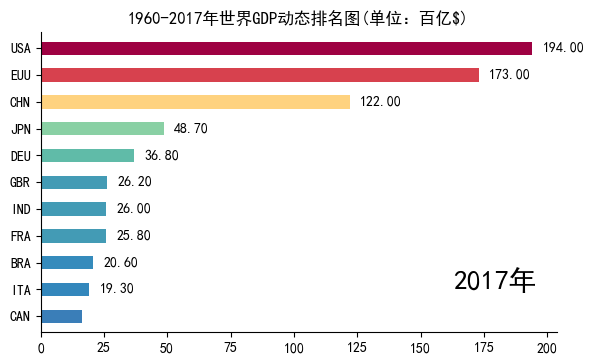

In [9]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd
import numpy as np
import matplotlib.animation as animation

# 配置全局参数
plt.rcParams.update({
    'font.sans-serif': ['SimHei'],
    'axes.unicode_minus': False,
    'animation.embed_limit': 2**128
})

# 读取数据
df = pd.read_csv('country_gdp.csv', index_col=1)  # 使用正确的文件路径

# 计算排名
for year in range(1960, 2018):
    df[f'{year}_rank'] = 11 - df[str(year)].rank(ascending=False)

# 绘制GDP动态条形图
def draw_gdp(frame):
    ax.clear()
    year_start = 1960 + frame // 10
    next_year = year_start + 1
    step = frame % 10

    if frame < 570:
        rank_val = interpolate(df, year_start, next_year, step, '_rank')
        gdp_val = interpolate(df, year_start, next_year, step)
    else:
        rank_val = df[f'{year_start}_rank']
        gdp_val = df[str(year_start)]

    render_bar_chart(rank_val, gdp_val, year_start)

# 插值函数
def interpolate(df, year_start, next_year, step, suffix=''):
    return (df[f'{next_year}{suffix}'] - df[f'{year_start}{suffix}']) / 10 * step + df[f'{year_start}{suffix}']

# 渲染条形图函数
def render_bar_chart(rank_val, gdp_val, year_start):
    gdp_val = gdp_val / 1e11
    valid_rank = rank_val[(rank_val >= 0) & (rank_val < 11)]

    # 保证 gdp_val 和 valid_rank 的长度一致
    gdp_val = gdp_val.loc[valid_rank.index]

    colors = cm.Spectral_r(gdp_val.values / gdp_val.max())
    bars = ax.barh(valid_rank.values, gdp_val.values, height=0.5, color=colors)

    # 设置图表参数
    format_chart(year_start, valid_rank)

    # 在条形图上添加GDP数值
    for bar in bars:
        if bar.get_y() > 0:
            plt.text(bar.get_width() + 0.02 * ax.get_xlim()[1], bar.get_y() + 0.125, f'{bar.get_width():.2f}')


# 图表参数设置函数
def format_chart(year_start, valid_rank):
    ax.set_ylim(-0.6, 10.6)
    ax.spines['top'].set_color('none')
    ax.spines['right'].set_color('none')

    ax.set_yticks(valid_rank.values)
    ax.set_yticklabels(valid_rank.index)
    ax.text(0.8 * ax.get_xlim()[1], 1, f'{year_start}年', fontsize=20)
    ax.set_title("1960-2017年世界GDP动态排名图(单位：百亿$)")

# 创建图表并保存动画
fig, ax = plt.subplots(figsize=(6, 4), dpi=100)
plt.subplots_adjust(left=0.12, right=0.98, top=0.85, bottom=0.1, hspace=0, wspace=0)

animator = animation.FuncAnimation(fig, draw_gdp, np.arange(0, 571, 1), interval=100)
animator.save('gdp.gif', writer='pillow', savefig_kwargs={'facecolor': 'white'}, fps=10)
plt.show()
